<a href="https://colab.research.google.com/github/MunagotiAparna/BusBooking/blob/main/Week_3_Sentiment_Analysis_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 3 Task: Implementing Sentiment Analysis and Named Entity Recognition

Name: Aparna Munagoti,
Task: Week 3,
Domain: Natural Language Processing.

In [ ]:
!pip install -q kagglehub spacy datasets
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import kagglehub

In [ ]:
path = kagglehub.dataset_download(
    "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
import os

print(os.listdir(path))

['IMDB Dataset.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "IMDB Dataset.csv"))

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Shape: (50000, 2)

Columns:
Index(['review', 'sentiment'], dtype='object')

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
def clean_text(text):
    text = re.sub(r"<.*?>", "", text)       # Remove HTML tags
    text = text.lower()                     # Convert to lowercase
    text = re.sub(r"[^a-z\s]", "", text)   # Keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...,positive


In [ ]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_review"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40000
Testing samples: 10000


In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

Training feature shape: (40000, 10000)
Testing feature shape: (10000, 10000)


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8997
Accuracy (%): 89.97


In [ ]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Precision: 0.8934829690884032
Recall: 0.9076
F1-score: 0.9004861593412045


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



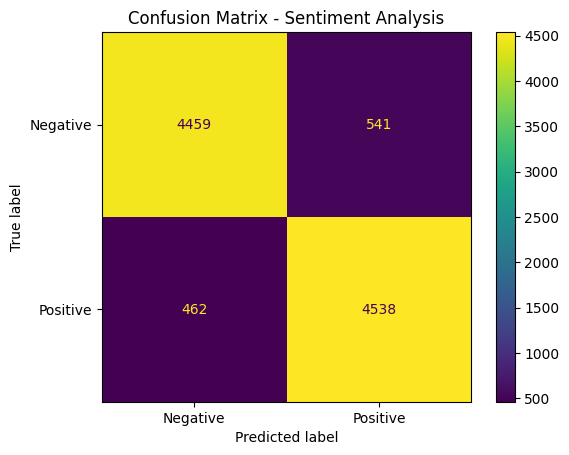

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

In [ ]:
sample_reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was boring and disappointing.",
    "A wonderful film with excellent acting and a great story.",
    "I hated this movie. It was a complete waste of time."
]

sample_clean = [clean_text(review) for review in sample_reviews]

sample_features = tfidf.transform(sample_clean)

sample_predictions = model.predict(sample_features)

for review, prediction in zip(sample_reviews, sample_predictions):
    sentiment = "Positive" if prediction == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print()

Review: This movie was absolutely amazing and I loved every minute of it.
Predicted Sentiment: Positive

Review: The movie was boring and disappointing.
Predicted Sentiment: Negative

Review: A wonderful film with excellent acting and a great story.
Predicted Sentiment: Positive

Review: I hated this movie. It was a complete waste of time.
Predicted Sentiment: Negative



Named Entity Recognition.

In [ ]:
import spacy
from datasets import load_dataset

In [ ]:
nlp = spacy.load("en_core_web_sm")

print("spaCy NER model loaded successfully!")

spaCy NER model loaded successfully!


In [ ]:
from datasets import load_dataset

ner_dataset = load_dataset(
    "lhoestq/conll2003",
    trust_remote_code=True
)

print(ner_dataset)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lhoestq/conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lhoestq/conll2003' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


dataset_infos.json:   0%|          | 0.00/3.67k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.07MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  281kB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})


In [ ]:
print(ner_dataset["train"].features)

{'id': Value('string'), 'tokens': List(Value('string')), 'pos_tags': List(Value('int64')), 'chunk_tags': List(Value('int64')), 'ner_tags': List(Value('int64'))}


In [ ]:
print(ner_dataset["train"][0]["tokens"])
print(ner_dataset["train"][0]["ner_tags"])

['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
[3, 0, 7, 0, 0, 0, 7, 0, 0]


In [ ]:
text = """
Apple CEO Tim Cook visited London and met with Microsoft executives.
The meeting was held on August 15, 2026.
"""

doc = nlp(text)

for ent in doc.ents:
    print(ent.text, "->", ent.label_)

Apple -> ORG
Tim Cook -> PERSON
London -> GPE
Microsoft -> ORG
August 15, 2026 -> DATE


In [ ]:
from spacy import displacy

displacy.render(doc, style="ent", jupyter=True)

In [ ]:
def convert_labels(label_ids):
    return [label_names[label_id] for label_id in label_ids]

tokens = ner_dataset["train"][0]["tokens"]
labels = ner_dataset["train"][0]["ner_tags"]

converted_labels = convert_labels(labels)

for token, label in zip(tokens, converted_labels):
    print(token, "->", label)

EU -> B-ORG
rejects -> O
German -> B-MISC
call -> O
to -> O
boycott -> O
British -> B-MISC
lamb -> O
. -> O


In [ ]:
def extract_entities(tokens, labels):
    entities = []
    current_entity = []
    current_type = None

    for token, label in zip(tokens, labels):

        if label.startswith("B-"):
            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )

            current_entity = [token]
            current_type = label[2:]

        elif label.startswith("I-") and current_entity:
            current_entity.append(token)

        else:
            if current_entity:
                entities.append(
                    (" ".join(current_entity), current_type)
                )
                current_entity = []
                current_type = None

    if current_entity:
        entities.append(
            (" ".join(current_entity), current_type)
        )

    return entities

In [ ]:
entities = extract_entities(tokens, converted_labels)

print("Extracted Entities:")

for entity, entity_type in entities:
    print(entity, "->", entity_type)

Extracted Entities:
EU -> ORG
German -> MISC
British -> MISC


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

true_entities = set()
pred_entities = set()

for example_id, example in enumerate(ner_dataset["test"].select(range(500))):

    tokens = example["tokens"]
    true_labels = convert_labels(example["ner_tags"])

    # True entities
    true_spans = extract_entities(tokens, true_labels)

    for entity in true_spans:
        true_entities.add(
            (example_id, entity[0], entity[1])
        )

    # spaCy prediction
    text = " ".join(tokens)
    doc = nlp(text)

    for ent in doc.ents:
        pred_entities.add(
            (example_id, ent.text, ent.label_)
        )

In [ ]:
true_positive = len(true_entities & pred_entities)
false_positive = len(pred_entities - true_entities)
false_negative = len(true_entities - pred_entities)

precision_ner = (
    true_positive / (true_positive + false_positive)
    if true_positive + false_positive > 0 else 0
)

recall_ner = (
    true_positive / (true_positive + false_negative)
    if true_positive + false_negative > 0 else 0
)

f1_ner = (
    2 * precision_ner * recall_ner /
    (precision_ner + recall_ner)
    if precision_ner + recall_ner > 0 else 0
)

print("NER Precision:", precision_ner)
print("NER Recall:", recall_ner)
print("NER F1-score:", f1_ner)

NER Precision: 0.03485064011379801
NER Recall: 0.050411522633744855
NER F1-score: 0.04121110176619008


In [ ]:
results = pd.DataFrame({
    "Task": [
        "Sentiment Analysis",
        "Named Entity Recognition"
    ],
    "Precision": [
        precision,
        precision_ner
    ],
    "Recall": [
        recall,
        recall_ner
    ],
    "F1-Score": [
        f1,
        f1_ner
    ]
})

results

,Task,Precision,Recall,F1-Score
0,Sentiment Analysis,0.893483,0.907600,0.900486
1,Named Entity Recognition,0.034851,0.050412,0.041211
